In [49]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.1.2 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, BatchNormalization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, recall_score, precision_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
import kagglehub
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pandas as pd

In [51]:
# Usando el path del dataset definido
path = kagglehub.dataset_download("abdulmananraja/real-life-violence-situations")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\valen\.cache\kagglehub\datasets\abdulmananraja\real-life-violence-situations\versions\1


In [52]:
# Verificar la carpeta base
print("Contenido de la carpeta base:", os.listdir(path))

Contenido de la carpeta base: ['new_violence']


In [53]:
violence_images = os.path.join(path, "new_violence", "violence")
non_violence_images = os.path.join(path, "new_violence", "non_violence")
images = []
labels = []

def load_images(path, label):
    for image in os.listdir(path):
        image_path = os.path.join(path, image)
        images.append(image_path)
        labels.append(label)

load_images(violence_images, 1)
load_images(non_violence_images, 0)

In [54]:
# Crear un DataFrame con las rutas de las imágenes y sus respectivas etiquetas
df = pd.DataFrame()
df["images"] = images
df["labels"] = labels
print(df.head())


                                              images  labels
0  C:\Users\valen\.cache\kagglehub\datasets\abdul...       1
1  C:\Users\valen\.cache\kagglehub\datasets\abdul...       1
2  C:\Users\valen\.cache\kagglehub\datasets\abdul...       1
3  C:\Users\valen\.cache\kagglehub\datasets\abdul...       1
4  C:\Users\valen\.cache\kagglehub\datasets\abdul...       1


In [55]:
# Normalizar las imágenes
def normalize_image(image_path):
    image = Image.open(image_path)
    image = image.resize((128, 128))
    image = np.array(image)
    image = image / 255.0
    return image

df["images"] = df["images"].apply(normalize_image)

In [56]:
data = list(zip(df['images'], df['labels']))
np.random.shuffle(data)

In [57]:
# Dividir el dataset en entrenamiento, validación y prueba
train_data = data[:int(0.7*len(data))]
val_data = data[int(0.7*len(data)):int(0.85*len(data))]
test_data = data[int(0.85*len(data)):]

X_train, y_train = zip(*train_data)
X_val, y_val = zip(*val_data)
X_test, y_test = zip(*test_data)

X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

In [ ]:
model = tf.keras.models.Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

c:\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
earlyStopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), callbacks=[earlyStopping])

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,070,401 (49.86 MB)

 Trainable params: 13,070,401 (49.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 73s 283ms/step - accuracy: 0.6306 - loss: 0.6167 - val_accuracy: 0.8152 - val_loss: 0.3886
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 74s 305ms/step - accuracy: 0.8171 - loss: 0.3775 - val_accuracy: 0.8754 - val_loss: 0.2764
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 62s 257ms/step - accuracy: 0.8935 - loss: 0.2559 - val_accuracy: 0.8772 - val_loss: 0.2775
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 62s 255ms/step - accuracy: 0.9253 - loss: 0.1867 - val_accuracy: 0.9019 - val_loss: 0.2704
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 71s 293ms/step - accuracy: 0.9546 - loss: 0.1244 - val_accuracy: 0.8808 - val_loss: 0.4329
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 83s 295ms/step - accuracy: 0.9720 - loss: 0.0722 - val_accuracy: 0.9019 - val_loss: 0.2862
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 71s 294ms/step - accuracy: 0.9797 - loss: 0.0624 - val_accuracy: 0.9193 - val_loss: 0.2874
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 71s 292ms/step - accuracy: 0.9840 - loss: 0

In [62]:
# Evaluar el modelo
loss, accuracy = model.evaluate(X_val, y_val)

52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9063 - loss: 0.2533


In [39]:
# Hacer predicciones en el conjunto de prueba
y_pred = model.predict(X_val)
y_pred = np.round(y_pred)

70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step


In [40]:
# Calcular métricas 
accuracy = accuracy_score(y_val, y_val)
f1 = f1_score(y_val, y_val)
recall = recall_score(y_val, y_val)
precision = precision_score(y_val, y_val)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)

Accuracy: 0.9218961625282167
F1 Score: 0.9287185826122786
Recall: 0.9462636439966414
Precision: 0.9118122977346278


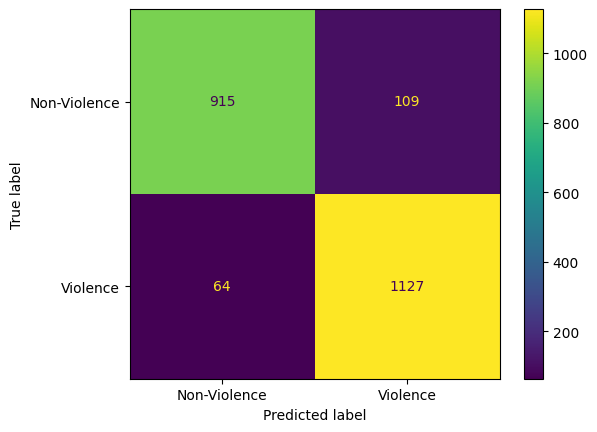

In [41]:
# Matriz de confusión
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Violence", "Violence"])
disp.plot()
plt.show()

In [42]:
# Reporte de clasificación
report = classification_report(y_val, y_pred, target_names=["Non-Violence", "Violence"])
print(report)

              precision    recall  f1-score   support

Non-Violence       0.93      0.89      0.91      1024
    Violence       0.91      0.95      0.93      1191

    accuracy                           0.92      2215
   macro avg       0.92      0.92      0.92      2215
weighted avg       0.92      0.92      0.92      2215



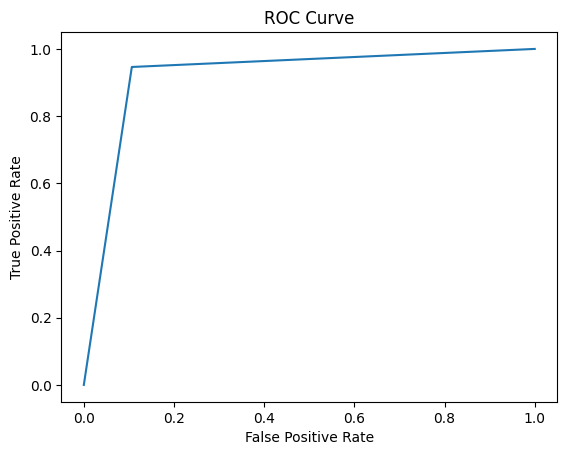

AUC: 0.9199091657483207


In [43]:
# AUC y ROC
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

auc = roc_auc_score(y_val, y_pred)
print("AUC:", auc)

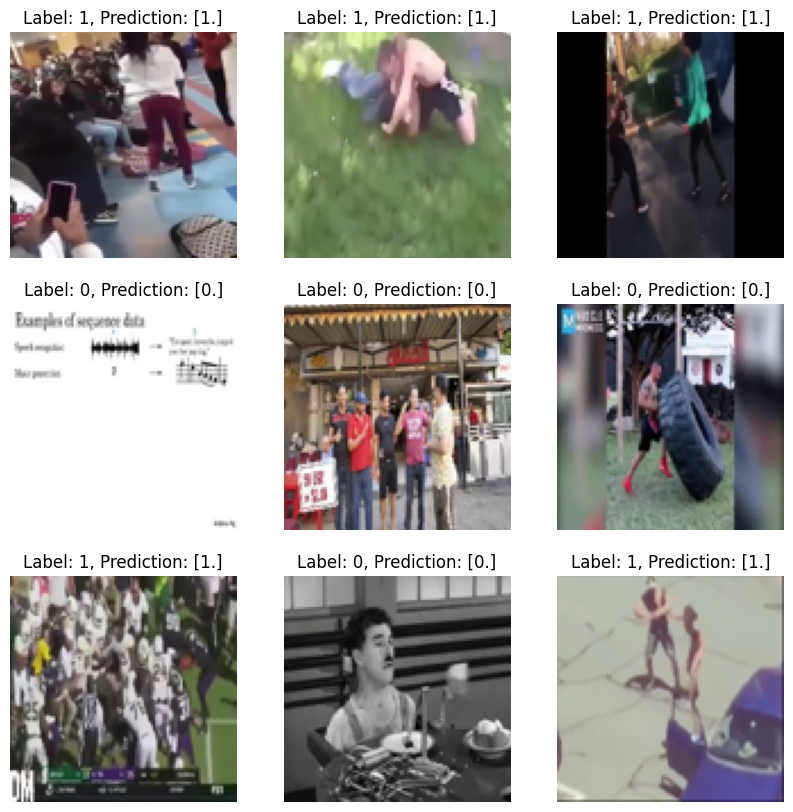

In [45]:
# Mostrar algunas predicciones
violence_dict = {0: "Non-Violence", 1: "Violence"}
def show_predictions(images, labels, predictions):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(f"Actual: {violence_dict[labels[i]]}, Predicted: {violence_dict[predictions[i][0]]}")
        plt.axis("off")
    plt.show()

show_predictions(X_val, y_val, y_pred)